## Data Load

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Objetives

The objetive we have with this project is to analyze to identify the key factors that contributes to this costumer attrition

Costumer churn suppose a critical problem for SaaS business, which impacts revenue and growth

### Key Questions

* What is the overall churn rate?
* Which segments are more likely to churn?
* Does the contract affect?
* How do monthly charges relate to churn?
* Are long-term customers less likely to churn?

We will study this problem, and ensure a solution to it

### Exploration Data Analysis (EDA)

In [ ]:
churn_rate = df["Churn"].value_counts(
    normalize=True
)  # Proportion of costumers in each churn category
churn_rate = (churn_rate * 100).round(2).astype(str) + "%"  # Churn rate in %
churn_rate

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str

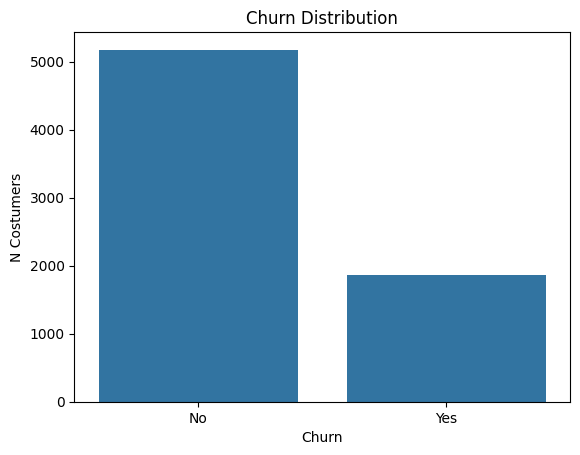

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")  # Data visualization
plt.xlabel("Churn")
plt.ylabel("N Costumers")
plt.show()

### Insights

* Most of costumers have not churned, which indicates the company stills retains a large proportion of its costumers
* 26.54% of the costumers churned, we need to understand the reasons behind because it supposes a significant loss
* A churn rate of this magninute suggest that costumers retention should be a strategic priority


## Costumer Segments

### Contract type

In [ ]:
pd.crosstab(
    df["Contract"], df["Churn"], normalize="index"
) * 100  # We extract the clients and the churn by their contact

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


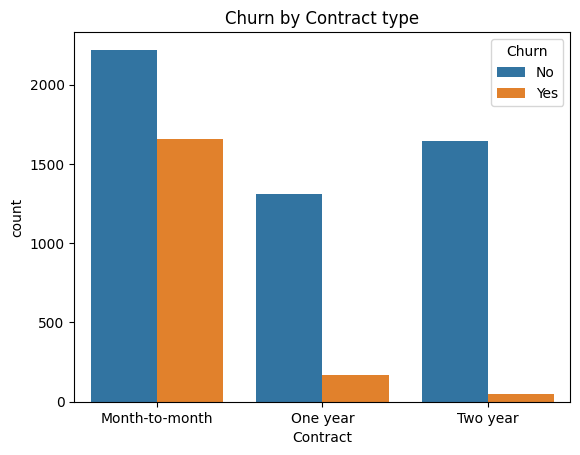

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract type")
plt.show()

We see that the clients month-to-month are more likely to churn with difference

### Payment method

In [ ]:
pd.crosstab(df["Churn"], df["PaymentMethod"], normalize="index") * 100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,24.855044,24.932354,25.009664,25.202938
Yes,13.804173,12.413055,57.303371,16.479401


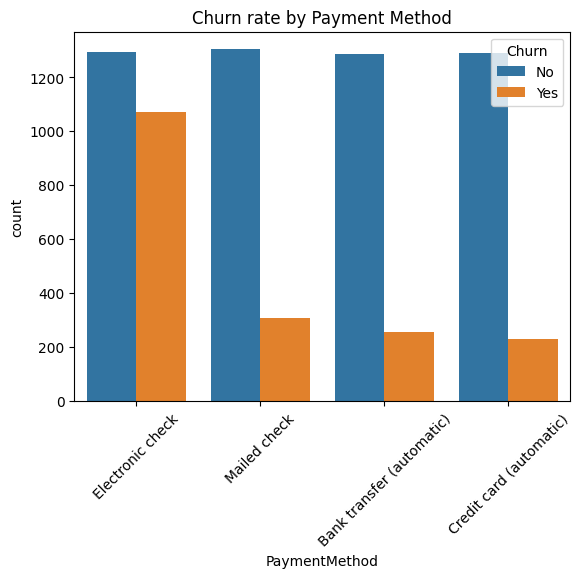

In [ ]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn rate by Payment Method")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# % of churns in every type of payment method
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="columns") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),24.855044,13.804173
Credit card (automatic),24.932354,12.413055
Electronic check,25.009664,57.303371
Mailed check,25.202938,16.479401


As we see electronic check is by far the most common payment method by which costumers churn

### Tenure

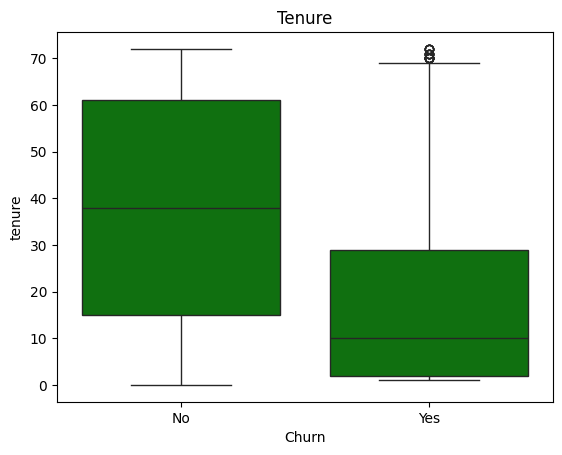

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df, color="green")
plt.title("Tenure")
plt.show()

### Monthly and Total Charges

In [ ]:
# We first clean the data TotalCharges as it is shown as string(object)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()  # We count what null values have to remove them

np.int64(11)

In [ ]:
df = df.dropna(subset=["TotalCharges"])

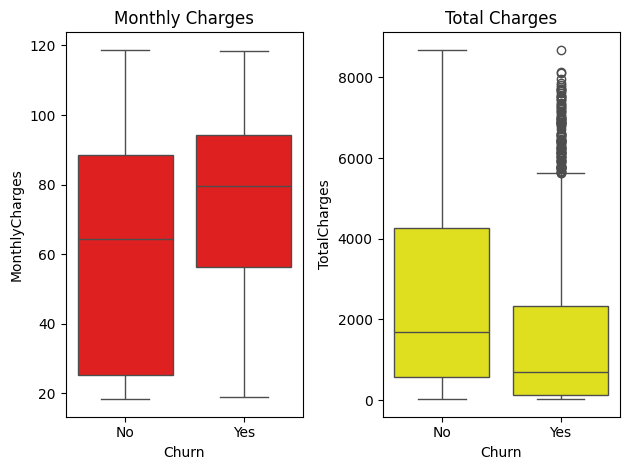

In [ ]:
# Monthly charges
plt.subplot(1, 2, 1)
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, color="red")
plt.title("Monthly Charges")

# Total Charges
plt.subplot(1, 2, 2)
sns.boxplot(x="Churn", y="TotalCharges", data=df, color="yellow")
plt.title("Total Charges")

plt.tight_layout()
plt.show()

### Insights

- Customers who have recently joined are more likely to churn. However, some long-tenure customers also show churn behavior, indicating that retention issues are not limited to new users.

- Customers with lower monthly charges tend to stay, suggesting that higher pricing may contribute to customer dissatisfaction and increased churn risk.

- Customers with lower total charges are more likely to churn, indicating that churn is more common among customers with shorter relationships with the company.

## Final Insights

This section summarizes the key findings from the exploratory data analysis.

### Key Findings

- Customers with month-to-month contracts show significantly higher churn rates compared to those with long-term contracts.

- Customers who churn tend to have higher monthly charges, suggesting that pricing may be a key factor influencing customer dissatisfaction.

- Churn is more common among customers with lower total charges, indicating that customers tend to leave during the early stages of their relationship with the company.

- Customer tenure plays a critical role in retention, with newer customers being more likely to churn than long-term customers.

- Payment method and service type also show variations in churn behavior, suggesting that certain customer segments may be at higher risk.